In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import trange

In [3]:
from dataset import SuctionGraspingDataset, data_transform
from model import RGBDResNet101
from metrics import masked_bce_loss, masked_mse_loss

In [4]:
data_path = Path('../data')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model = RGBDResNet101(num_classes=1, pretrained=True)
model = model.to(device).eval()

In [6]:
test_dataset = SuctionGraspingDataset(
    data_path=data_path,
    sample_list=data_path / "test-split.txt",
    transform=data_transform
)
train_dataset = SuctionGraspingDataset(
    data_path=data_path,
    sample_list=data_path / "train-split.txt",
    transform=data_transform
)

In [11]:
def evaluate(model: RGBDResNet101, dataset: SuctionGraspingDataset, prefix: str = ''):
    loss_sum = 0
    mse_sum = 0
    n = len(dataset)
    for i in trange(n):
        color, depth, label = dataset[i]
        color = color[None].to(device)
        depth = depth[None].to(device)
        label = label[None].to(device)

        with torch.no_grad():
            output = model(color, depth)
            loss = masked_bce_loss(output, label).cpu().item()
            mse = masked_mse_loss(F.sigmoid(output), label).cpu().item()

        loss_sum += loss
        mse_sum += mse

    return {
        prefix + 'loss': loss_sum / n,
        prefix + 'mse': mse_sum / n
    }

In [8]:
snapshot_iterations = [int(file.split('-')[1][:-3]) for file in os.listdir('snapshots')]
snapshot_iterations.sort()

In [20]:
results = []

model = RGBDResNet101(num_classes=1, pretrained=True).to(device).eval()

metrics_train = evaluate(model, train_dataset, prefix='train_')
print(metrics_train)
metrics_test = evaluate(model, test_dataset, prefix='test_')
print(metrics_test)
results.append({"iter_num": 0} | metrics_train | metrics_test)

  0%|          | 0/1470 [00:00<?, ?it/s]

{'train_loss': 0.5274433074962526, 'train_mse': 0.17024786983724355}


  0%|          | 0/367 [00:00<?, ?it/s]

{'test_loss': 0.5291973143734789, 'test_mse': 0.17140639697173635}


In [ ]:
for iter_num in snapshot_iterations:
    print("Evaluating iteration", iter_num)

    checkpoint = torch.load(f"snapshots/snapshot-{iter_num}.pt", map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model'])
    model = model.to(device).eval()

    metrics_train = evaluate(model, train_dataset, prefix='train_')
    print(metrics_train)
    metrics_test = evaluate(model, test_dataset, prefix='test_')
    print(metrics_test)
    results.append({"iter_num": iter_num} | metrics_train | metrics_test)

In [23]:
df = pd.DataFrame(results).set_index('iter_num').sort_index()
df

,train_loss,train_mse,test_loss,test_mse
iter_num,,,,
0,0.527443,0.170248,0.529197,0.171406
1000,0.202366,0.060977,0.235411,0.071289
2000,0.174874,0.052343,0.241008,0.070931
3000,0.146461,0.043738,0.239751,0.071364
4000,0.103831,0.030126,0.266852,0.070803
5000,0.078670,0.022794,0.250306,0.068080
6000,0.063513,0.018639,0.315983,0.072725
7000,0.056377,0.016500,0.302713,0.071016
8000,0.049959,0.014549,0.318683,0.072693


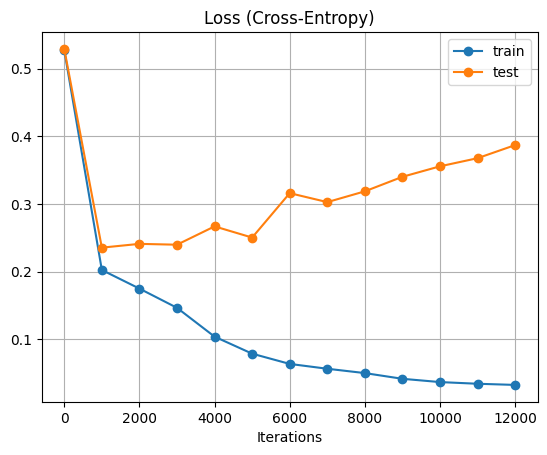

In [34]:
plt.plot(df.index, df['train_loss'], label='train', marker='o')
plt.plot(df.index, df['test_loss'], label='test', marker='o')
plt.title('Loss (Cross-Entropy)')
plt.xlabel('Iterations')
plt.legend()
plt.grid()
plt.show()

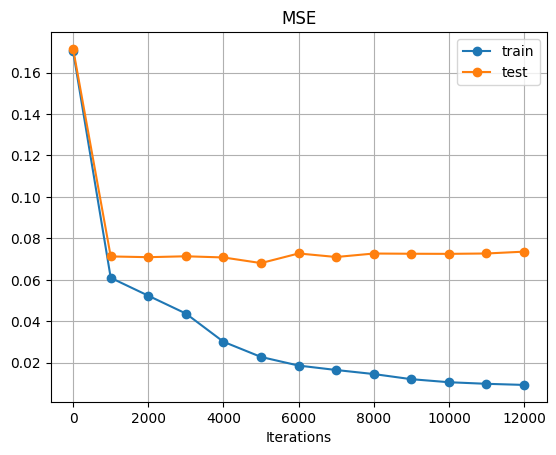

In [35]:
plt.plot(df.index, df['train_mse'], label='train', marker='o')
plt.plot(df.index, df['test_mse'], label='test', marker='o')
plt.title('MSE')
plt.xlabel('Iterations')
plt.legend()
plt.grid()
plt.show()